In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot


### Step 1 : Read the data file using pandas

In [ ]:
data = pd.read_csv("C:\\Users\\prana\\Downloads\\pranav\\CLUBS\\EPOCH\\clustering_data.csv",low_memory=False)
#need to write low_memory = False because the latitude col has strings line NA and other wrong data so pandas is not able to decide a datatype
print(data.ndim)
print(data.shape)
print(data.columns)
data


2
(157126, 11)
Index(['CircleName', 'RegionName', 'DivisionName', 'OfficeName', 'Pincode',
       'OfficeType', 'Delivery', 'District', 'StateName', 'Latitude',
       'Longitude'],
      dtype='object')


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Peddakotla B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5689,77.85624
1,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Pinnadhari B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5281,77.857014
2,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Yerraguntapalle B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.561111,77.85715
3,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Obulareddipalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.2488,78.2588
4,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Odulapalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.24555,78.2477
...,...,...,...,...,...,...,...,...,...,...,...
157121,Uttar Pradesh Circle,Bareilly Region,Meerut Division,Rly Road Meerut SO,250002,PO,Non Delivery,MEERUT,UTTAR PRADESH,28.98,77.68
157122,Uttar Pradesh Circle,Bareilly Region,Meerut Division,SGMandi SO,250002,PO,Non Delivery,MEERUT,UTTAR PRADESH,28.9724,77.67536
157123,Uttar Pradesh Circle,Bareilly Region,Meerut Division,W K Road SO,250001,PO,Non Delivery,MEERUT,UTTAR PRADESH,28.99,77.71
157124,Kerala Circle,Calicut Region,Calicut Division,Kakkoti SO,673611,PO,Delivery,KOZHIKODE,KERALA,11.24529,75.778455


### Step 2: Now lets take the data of only the home state - MAHARASHTRA

In [ ]:
#now lets us use masking technique to sort the data with maharashtra state 
#.copy() forces pandas to create a completely independent dataframe in memory, so modifications only affect sorted_data and never the original data.
sorted_data = data[data["StateName"] == "MAHARASHTRA"].copy()                #.copy() creates a copy of the dataframe instead of the slice




#now we need to clean the data as some values are noisy like '19.93-' these are to be converted to numeric if possible or to NaN if not 
#errors='coerce' — any value that cannot be converted to a number is replaced with NaN instead of throwing an error
sorted_data['Latitude'] = pd.to_numeric(sorted_data['Latitude'], errors= 'coerce')
sorted_data['Longitude'] = pd.to_numeric(sorted_data['Longitude'], errors= 'coerce')




#remove the rows having NA or na or blank in the latitude and longitude col
sorted_data= sorted_data.dropna(subset=["Latitude", "Longitude"])



#now we need to remove all those noise data that is the coordinates that are not in the actual range of the state laatitudes and longitudes

sorted_data = sorted_data[(sorted_data['Latitude'] <= 22) & (sorted_data['Latitude']>=15) & (sorted_data['Longitude'] <= 80) & (sorted_data['Longitude']>=72)]
#remove all duplicates
sorted_data = sorted_data.drop_duplicates(subset= ['Pincode'])
sorted_data



,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
934,Maharashtra Circle,Nagpur Region,Amaravati Division,Bhatkuli S.O,444602,PO,Non Delivery,AMRAVATI,MAHARASHTRA,20.907000,77.602600
37630,Maharashtra Circle,Nagpur Region,Chandrapur Division,Subai B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.573344,79.442259
38709,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Nilegaon B.O,413603,BO,Delivery,OSMANABAD,MAHARASHTRA,18.010041,76.071064
38712,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Sukta B.O,413504,BO,Delivery,OSMANABAD,MAHARASHTRA,18.449512,75.675819
38716,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Dhanuri B.O,413604,BO,Delivery,OSMANABAD,MAHARASHTRA,17.863953,76.478571
...,...,...,...,...,...,...,...,...,...,...,...
156384,Maharashtra Circle,Navi Mumbai Region,Nasik Division,Cidco Colony S.O (Nashik),422009,PO,Delivery,NASHIK,MAHARASHTRA,19.988439,73.720725
156386,Maharashtra Circle,Navi Mumbai Region,Nasik Division,H P T College S.O,422005,PO,Delivery,NASHIK,MAHARASHTRA,19.988439,73.720725
156809,Maharashtra Circle,Nagpur Region,Chandrapur Division,Ballarpur Paper Mill S.O,442901,PO,Delivery,CHANDRAPUR,MAHARASHTRA,19.861250,79.341778
156812,Maharashtra Circle,Nagpur Region,Chandrapur Division,Chandrapur Ord Fact S.O,442501,PO,Delivery,CHANDRAPUR,MAHARASHTRA,20.117111,79.149417


### Step 3: plotting 

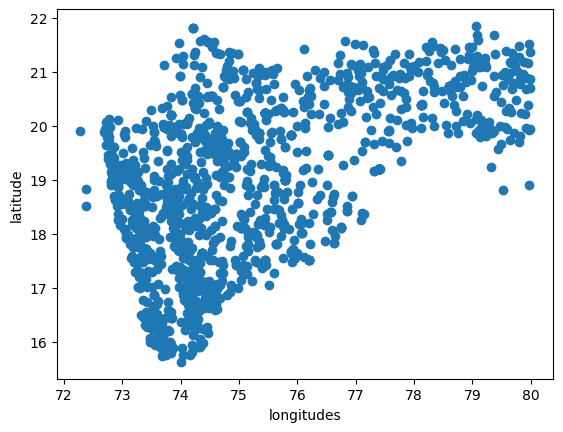

In [ ]:
plot.scatter(sorted_data["Longitude"],sorted_data["Latitude"])
plot.xlabel("longitudes")
plot.ylabel("latitude")
plot.show()


# writing the clustering code

In [ ]:
data_np = sorted_data[['Latitude','Longitude']].values   #converted to np
data_np

array([[20.907    , 77.6026   ],
       [19.5733438, 79.4422593],
       [18.010041 , 76.0710641],
       ...,
       [19.86125  , 79.3417778],
       [20.1171111, 79.1494167],
       [16.4310833, 74.1414444]], shape=(1576, 2))

first we need to randomly choose points as centroids to start with 

In [ ]:
def initialize_centroid (X,k):
    centroids_idx = np.random.choice(len(X), k, replace=False) 
    return X[centroids_idx]




now we give the cluster labels according to the centroid that is closest, (label is index of the centroid in the array)

In [ ]:
def create_cluster (X,centroids):
    labels = []
    for point in X:
        distance = np.sqrt(np.sum((centroids - point)**2, axis=1))          #axis=1 sums across each row 
        min_distance_idx = np.argmin(distance)
        labels.append(min_distance_idx)
    return  labels

now we update the centroids to the mean of all the points with the same cluster label

In [ ]:
def update_centroid (X,labels,k):
    updated_centroids = []
    for i in range(k) :
        cluster = X[labels == i]
        updated_centroids.append(np.mean(cluster,axis = 0))
    
    return updated_centroids


Now writing the final k_means logic 

In [ ]:
def k_means (X,max_iterations = 100,k=5):
    centroids = initialize_centroid(X,k)
    labels_for_points=[]
    updated_centroid = centroids
    while (max_iterations):                                                             #the loop works till max iteration or until no update is made
        
        labels_for_points =np.array( create_cluster(X,centroids))                           #get the labels for all points
        updated_centroid = update_centroid(X,labels_for_points,k)
        if np.allclose(updated_centroid,centroids):                                         #np.allclose check for equality
            break
        max_iterations = max_iterations -1
        centroids = updated_centroid 

    return labels_for_points

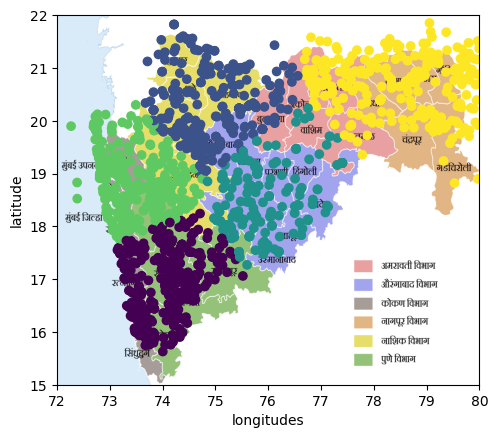

In [ ]:
labels = k_means(data_np,k=5)
MH_png=plot.imread("C:\\Users\\prana\\Downloads\\pranav\\CLUBS\\EPOCH\\Maharashtra_locator_map.png")
plot.imshow(MH_png,extent=[72, 80, 15, 22])
plot.scatter(sorted_data["Longitude"],sorted_data["Latitude"],c=labels)
plot.xlabel("longitudes")
plot.ylabel("latitude")
plot.show()


# Inference :

The points almost appropriately separate according to the regions of maharashtra:
green => parts of kokan (western ghat) and parts of north and west maharashtra
purple => majorly west maharashtra
yellow => majorly north maharashtra
dark green => majorly marathwada
blue => majorly vidarbha  

### the points are significantly dense on the places of high population density as more no of post-offices are required so more no. of pincodes are required
